# 09 | Nadir-window reflection: bounded diagnostic

The nadir port is a protective optical window in the nadir viewing path. The project briefing proposes that a small fraction of laser pulses may reflect internally at a window face, re-enter the receiver path, and produce a strong non-geophysical ghost return. This mechanism remains a **hypothesis** here. A proposed signature is an early, unusually strong return that recurs at a stable bin, is localized by track, and varies weakly with scene structure. This notebook tests for that pattern in one bounded November 18 block. A transient by itself is not enough to identify a window reflection.

Any candidate bands are research flags for downstream filtering. They are not official corrections or L2 products. The preferred response to a supported candidate is **flag + downstream filtering**; template subtraction remains exploratory and can remove scene energy.

## Data selection and analysis limits

The block is **sweeps 11994-12083** (90 sweeps, 256 tracks per sweep), centered on the already reviewed road-context pulse at sweep 12039 / track 68. That anchor makes the block easy to trace and supplies a nearby scene comparison; the pulse label itself is not used as ground truth. This reads about 0.64% of the November 18 granule's RX records. The sweep/track grid is read in full as scalar bookkeeping; RX waveforms are read only for this block.

The early-bin gate is capped at bin 1200 and shortened if needed to stay at least 80 bins before the 1st percentile of the block's raw RX maxima. Occupancy is the fraction of selected sweeps exceeding 5 times the H5 `bg_std` at one fixed track/bin. Candidate extraction additionally requires occupancy >= 20%, median exceedance >= 5 sigma, and score >= 0.45. These are conservative screening rules, not calibrated sensor thresholds. `refh` variation is only a scene-dependence proxy and is not an independent scene label.


In [1]:
from pathlib import Path
import json, sys
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from IPython.display import display, Image

ROOT = Path.cwd()
if not (ROOT / "casals_l1b").is_dir():
    raise RuntimeError("Start Jupyter from the CASALS repository root.")
sys.path.insert(0, str(ROOT))
from research.nadir_window_reflection import (
    extract_candidate_bands, flag_bins, mask_bins, read_sweep_block,
    score_track_bins, subtract_template,
)
from research.waveform_decomposition import estimate_baseline, fit_gaussian_components
from casals_l1b.peaks_cli import build_detector_config, default_config
from casals_l1b.waveform import detect_candidate_components_1d

H5_PATH = ROOT / "data/raw/casals_l1b/casals_l1b_20241118T171757_001_02.h5"
if not H5_PATH.is_file():
    raise FileNotFoundError(f"Missing real CASALS L1B input: {H5_PATH}")
OUTPUT_DIR = ROOT / "outputs/notebooks/09_nadir_window_reflection/scientific_review" / H5_PATH.stem
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
START_SWEEP, STOP_SWEEP = 11994, 12084  # stop is exclusive
ANCHOR_SWEEP, ANCHOR_TRACK = 12039, 68
MAX_EARLY_BINS, PRE_RETURN_MARGIN = 1200, 80
THRESHOLD_SIGMA = 5.0
OCCUPANCY_MIN, EXCESS_SIGMA_MIN, SCORE_MIN = 0.20, 5.0, 0.45
DPI = 190
plt.rcParams.update({"font.family": "DejaVu Sans", "font.size": 10,
                     "axes.spines.top": False, "axes.spines.right": False})

print({"input": str(H5_PATH.relative_to(ROOT)), "selected_sweeps": [START_SWEEP, STOP_SWEEP - 1],
       "anchor": {"sweep": ANCHOR_SWEEP, "track": ANCHOR_TRACK},
       "output": str(OUTPUT_DIR.relative_to(ROOT))})

{'input': 'data\\raw\\casals_l1b\\casals_l1b_20241118T171757_001_02.h5', 'selected_sweeps': [11994, 12083], 'anchor': {'sweep': 12039, 'track': 68}, 'output': 'outputs\\notebooks\\09_nadir_window_reflection\\scientific_review\\casals_l1b_20241118T171757_001_02'}


## Bounded read and traceable identities

`record_index_grid[sweep, track]` is the sole mapping from the displayed sweep/track coordinates to flat H5 pulse indices. The RX subset, corresponding background statistics, Refh values and coordinates are read together. Missing/duplicate grid cells stop the notebook rather than silently changing identities.

In [2]:
def read_scalar_block(h5, name, ids):
    flat = np.asarray(ids, dtype=np.int64).reshape(-1)
    order = np.argsort(flat)
    restore = np.empty_like(order)
    restore[order] = np.arange(order.size)
    values = np.asarray(h5[name][flat[order]])[restore]
    return values.reshape(np.asarray(ids).shape)

with h5py.File(H5_PATH, "r") as h5:
    rx_block, index, record_ids = read_sweep_block(h5, "rx_waveform", START_SWEEP, STOP_SWEEP)
    if not index.complete_rectangular_grid or index.duplicate_sweep_track_cells:
        raise RuntimeError("The H5 sweep/track grid is not a unique complete rectangle.")
    scalar_names = ["bg_mean", "bg_std", "refh", "refh_snr", "refh_latitude", "refh_longitude", "refh_thres"]
    scalar = {name: read_scalar_block(h5, name, record_ids) for name in scalar_names}
    source_attrs = {key: str(value) for key, value in h5.attrs.items()}

raw_argmax = np.argmax(rx_block, axis=2)
p01 = int(np.floor(np.nanpercentile(raw_argmax, 1)))
EARLY_BINS = max(100, min(MAX_EARLY_BINS, p01 - PRE_RETURN_MARGIN))
if EARLY_BINS <= 0:
    raise RuntimeError("Could not define an early-bin interval for this selected block.")

pulse_count = int(record_ids.size)
block_info = {
    "sweep_start_inclusive": START_SWEEP,
    "sweep_stop_exclusive": STOP_SWEEP,
    "n_sweeps": STOP_SWEEP - START_SWEEP,
    "n_tracks": int(index.n_tracks),
    "n_selected_pulses": pulse_count,
    "fraction_of_granule_pulses": float(pulse_count / index.n_records),
    "rx_bins": int(rx_block.shape[2]),
    "raw_argmax_bin_percentiles": {str(q): float(np.nanpercentile(raw_argmax, q)) for q in [1, 5, 50, 95]},
    "early_bin_stop_exclusive": EARLY_BINS,
    "mapping": "verified build_record_index_grid; no flat-order assumption",
}
print(json.dumps(block_info, indent=2))
display(pd.DataFrame([block_info]))

{
  "sweep_start_inclusive": 11994,
  "sweep_stop_exclusive": 12084,
  "n_sweeps": 90,
  "n_tracks": 256,
  "n_selected_pulses": 23040,
  "fraction_of_granule_pulses": 0.006392045454545455,
  "rx_bins": 2728,
  "raw_argmax_bin_percentiles": {
    "1": 681.78,
    "5": 1698.0,
    "50": 1858.0,
    "95": 1928.0
  },
  "early_bin_stop_exclusive": 601,
  "mapping": "verified build_record_index_grid; no flat-order assumption"
}


,sweep_start_inclusive,sweep_stop_exclusive,n_sweeps,n_tracks,n_selected_pulses,fraction_of_granule_pulses,rx_bins,raw_argmax_bin_percentiles,early_bin_stop_exclusive,mapping
0,11994,12084,90,256,23040,0.006392,2728,"{'1': 681.78, '5': 1698.0, '50': 1858.0, '95':...",601,verified build_record_index_grid; no flat-orde...


## Fixed-bin recurrence and candidate score

For each track/bin, occupancy is the number of finite sweeps exceeding five background standard deviations divided by the number of finite sweeps at that exact bin. The score combines occupancy, robust exceedance amplitude, a low-weight early-bin prior, and a weak scene-association proxy. The 20% occupancy, 5-sigma, and 0.45 score gates are screening heuristics, not calibrated instrument thresholds. A candidate band requires all fixed gates and still requires human review; no threshold is tuned to force a reflection finding.

In [3]:
scores = score_track_bins(
    rx_block, scalar["bg_mean"], scalar["bg_std"], scalar["refh"],
    early_bins=EARLY_BINS, threshold_sigma=THRESHOLD_SIGMA,
)
candidate_bands = extract_candidate_bands(
    scores, occupancy_min=OCCUPANCY_MIN,
    median_excess_sigma_min=EXCESS_SIGMA_MIN, score_min=SCORE_MIN,
)
assert scores.valid_sweep_count.between(0, STOP_SWEEP - START_SWEEP).all()
assert np.allclose(scores.occupancy.to_numpy(),
                   np.divide(scores.event_count.to_numpy(), scores.valid_sweep_count.to_numpy(),
                             out=np.zeros(len(scores), dtype=float), where=scores.valid_sweep_count.to_numpy() > 0))
print("Per-bin finite-sweep denominator range:", int(scores.valid_sweep_count.min()), "to", int(scores.valid_sweep_count.max()))
display(scores.nlargest(10, "ghost_score")[
    ["track_num", "bin", "event_count", "valid_sweep_count", "occupancy",
     "median_excess_sigma", "ghost_score", "scene_assessed"]])
candidate_path = OUTPUT_DIR / "ghost_band_candidates.csv"
candidate_bands.to_csv(candidate_path, index=False)

z_early = (rx_block[:, :, :EARLY_BINS] - scalar["bg_mean"][:, :, None]) / np.maximum(
    scalar["bg_std"][:, :, None], 1e-6
)
early_peak_z = np.max(z_early, axis=2)
early_peak_bin = np.argmax(z_early, axis=2)
transient_rows = []
for flat_pos in np.argsort(early_peak_z.ravel())[-25:][::-1]:
    sweep_offset, track = np.unravel_index(int(flat_pos), early_peak_z.shape)
    pulse = int(record_ids[sweep_offset, track])
    transient_rows.append({
        "pulse_index": pulse, "sweep_num": int(START_SWEEP + sweep_offset),
        "track_num": int(track), "early_peak_bin": int(early_peak_bin[sweep_offset, track]),
        "early_peak_sigma": float(early_peak_z[sweep_offset, track]),
        "raw_argmax_bin": int(raw_argmax[sweep_offset, track]),
        "refh_m": float(scalar["refh"][sweep_offset, track]),
        "latitude": float(scalar["refh_latitude"][sweep_offset, track]),
        "longitude": float(scalar["refh_longitude"][sweep_offset, track]),
    })
transients = pd.DataFrame(transient_rows)
transients.to_csv(OUTPUT_DIR / "early_transient_review.csv", index=False)

# Rank one strongest early event for reproducible review; it remains unconfirmed without a band.
if candidate_bands.empty:
    screen = transients.iloc[0].to_dict()
    screen_status = "unconfirmed_single_transient"
    screen_reason = "No fixed-bin band passed the recurrence and amplitude gates; this is the strongest isolated early event only."
else:
    chosen_band = candidate_bands.sort_values(
        ["mean_ghost_score", "max_occupancy"], ascending=False, kind="stable"
    ).iloc[0]
    track = int(chosen_band.track_num)
    lo, hi = int(chosen_band.start_bin), int(chosen_band.end_bin)
    location = np.argwhere(record_ids[:, track] >= 0).ravel()
    band_z = z_early[location, track, lo : hi + 1]
    local = np.unravel_index(int(np.argmax(band_z)), band_z.shape)
    sweep_offset = int(location[local[0]])
    screen = {
        "pulse_index": int(record_ids[sweep_offset, track]),
        "sweep_num": int(START_SWEEP + sweep_offset), "track_num": track,
        "early_peak_bin": int(lo + local[1]), "early_peak_sigma": float(band_z[local]),
        "raw_argmax_bin": int(raw_argmax[sweep_offset, track]),
        "refh_m": float(scalar["refh"][sweep_offset, track]),
        "latitude": float(scalar["refh_latitude"][sweep_offset, track]),
        "longitude": float(scalar["refh_longitude"][sweep_offset, track]),
    }
    screen_status = "candidate_band_requires_review"
    screen_reason = "Selected from a recurring candidate band; attribution to a window reflection remains unverified."

local_track_refh = scalar["refh"][:, int(screen["track_num"])]
screen["local_track_refh_p10_m"] = float(np.nanpercentile(local_track_refh, 10))
screen["local_track_refh_median_m"] = float(np.nanmedian(local_track_refh))
screen["local_track_refh_p90_m"] = float(np.nanpercentile(local_track_refh, 90))
screen["refh_minus_local_median_m"] = float(screen["refh_m"] - screen["local_track_refh_median_m"])
if candidate_bands.empty:
    screen_reason += (f" Its H5 Refh is {screen['refh_m']:.2f} m; same-track P10-P90 is "
                      f"{screen['local_track_refh_p10_m']:.2f} to {screen['local_track_refh_p90_m']:.2f} m. "
                      "This isolated local outlier still has no established cause.")
screen_record = {"status": screen_status, "reason": screen_reason, "case": screen}
(OUTPUT_DIR / "window_reflection_selected_pulses.json").write_text(
    json.dumps({"h5": str(H5_PATH.relative_to(ROOT)), "selected_pulses": [screen_record]}, indent=2),
    encoding="utf-8",
)

leaders = scores.sort_values(["ghost_score", "occupancy", "median_excess_sigma"], ascending=False, kind="stable").head(30)
leaders.to_csv(OUTPUT_DIR / "early_bin_score_leaders.csv", index=False)

print({"candidate_bands": len(candidate_bands), "max_fixed_bin_occupancy": float(scores.occupancy.max()),
       "max_fixed_bin_event_count": int(scores.loc[scores.occupancy.idxmax(), "event_count"]),
       "max_fixed_bin_valid_sweeps": int(scores.loc[scores.occupancy.idxmax(), "valid_sweep_count"]),
       "pulses_with_early_peak_over_8sigma": int((early_peak_z > 8).sum()),
       "selected_screening_case": screen_record})
display(transients.head(10))
display(candidate_bands)

Per-bin finite-sweep denominator range: 90 to 90


,track_num,bin,event_count,valid_sweep_count,occupancy,median_excess_sigma,ghost_score,scene_assessed
29473,49,24,1,90,0.011111,9.261042,0.474502,True
29472,49,23,1,90,0.011111,9.331567,0.474469,True
86579,144,35,1,90,0.011111,9.214170,0.470708,True
105180,175,5,1,90,0.011111,9.048953,0.464515,True
105181,175,6,1,90,0.011111,8.924912,0.461291,True
86578,144,34,1,90,0.011111,8.641773,0.453684,True
34941,58,83,1,90,0.011111,9.083995,0.453286,True
107042,178,64,1,90,0.011111,8.227797,0.437950,True
86580,144,36,1,90,0.011111,8.125493,0.437785,True
34940,58,82,1,90,0.011111,8.507780,0.437593,True


{'candidate_bands': 0, 'max_fixed_bin_occupancy': 0.03333333333333333, 'max_fixed_bin_event_count': 3, 'max_fixed_bin_valid_sweeps': 90, 'pulses_with_early_peak_over_8sigma': 36, 'selected_screening_case': {'status': 'unconfirmed_single_transient', 'reason': 'No fixed-bin band passed the recurrence and amplitude gates; this is the strongest isolated early event only. Its H5 Refh is 183.09 m; same-track P10-P90 is -33.35 to -33.05 m. This isolated local outlier still has no established cause.', 'case': {'pulse_index': 3077720.0, 'sweep_num': 12022.0, 'track_num': 194.0, 'early_peak_bin': 415.0, 'early_peak_sigma': 11.407564375792198, 'raw_argmax_bin': 415.0, 'refh_m': 183.08787168612778, 'latitude': 36.193979068917855, 'longitude': -76.69926079742376, 'local_track_refh_p10_m': -33.34837930786992, 'local_track_refh_median_m': -33.166203697070294, 'local_track_refh_p90_m': -33.05387388865014, 'refh_minus_local_median_m': 216.25407538319809}}}

,pulse_index,sweep_num,track_num,early_peak_bin,early_peak_sigma,raw_argmax_bin,refh_m,latitude,longitude
0,3077720,12022,194,415,11.407564,415,183.087872,36.193979,-76.699261
1,3082899,12042,156,327,11.131010,327,196.147294,36.193950,-76.699289
2,3073249,12004,15,384,10.056703,1809,-33.305956,36.193808,-76.699292
3,3073248,12004,7,577,9.851148,1806,-33.260113,36.193790,-76.699287
4,3090726,12073,49,23,9.331566,1699,-33.325792,36.194190,-76.699577
5,3071492,11998,32,411,9.322998,1810,-33.315547,36.193823,-76.699281
6,3089682,12069,144,35,9.214171,1731,-33.215326,36.194407,-76.699645
7,3079038,12027,243,234,9.139979,1914,-33.170936,36.194483,-76.699580
8,3071559,11998,58,83,9.083995,1822,-33.738040,36.193885,-76.699303
9,3079925,12030,175,5,9.048953,1889,-33.111579,36.194325,-76.699533


,track_num,start_bin,end_bin,n_bins,mean_occupancy,max_occupancy,median_excess_counts,median_excess_sigma,mean_ghost_score,mean_scene_correlation,scene_assessed,max_persistence_sweeps


## Figure 09-A and overview

The first heatmap shows median background-corrected RX amplitude across this block for all tracks and bins. The overview separates early-bin occupancy from isolated per-pulse transients. Red outlines appear only for bands that pass the stated gates; an empty outline layer is a valid diagnostic outcome.

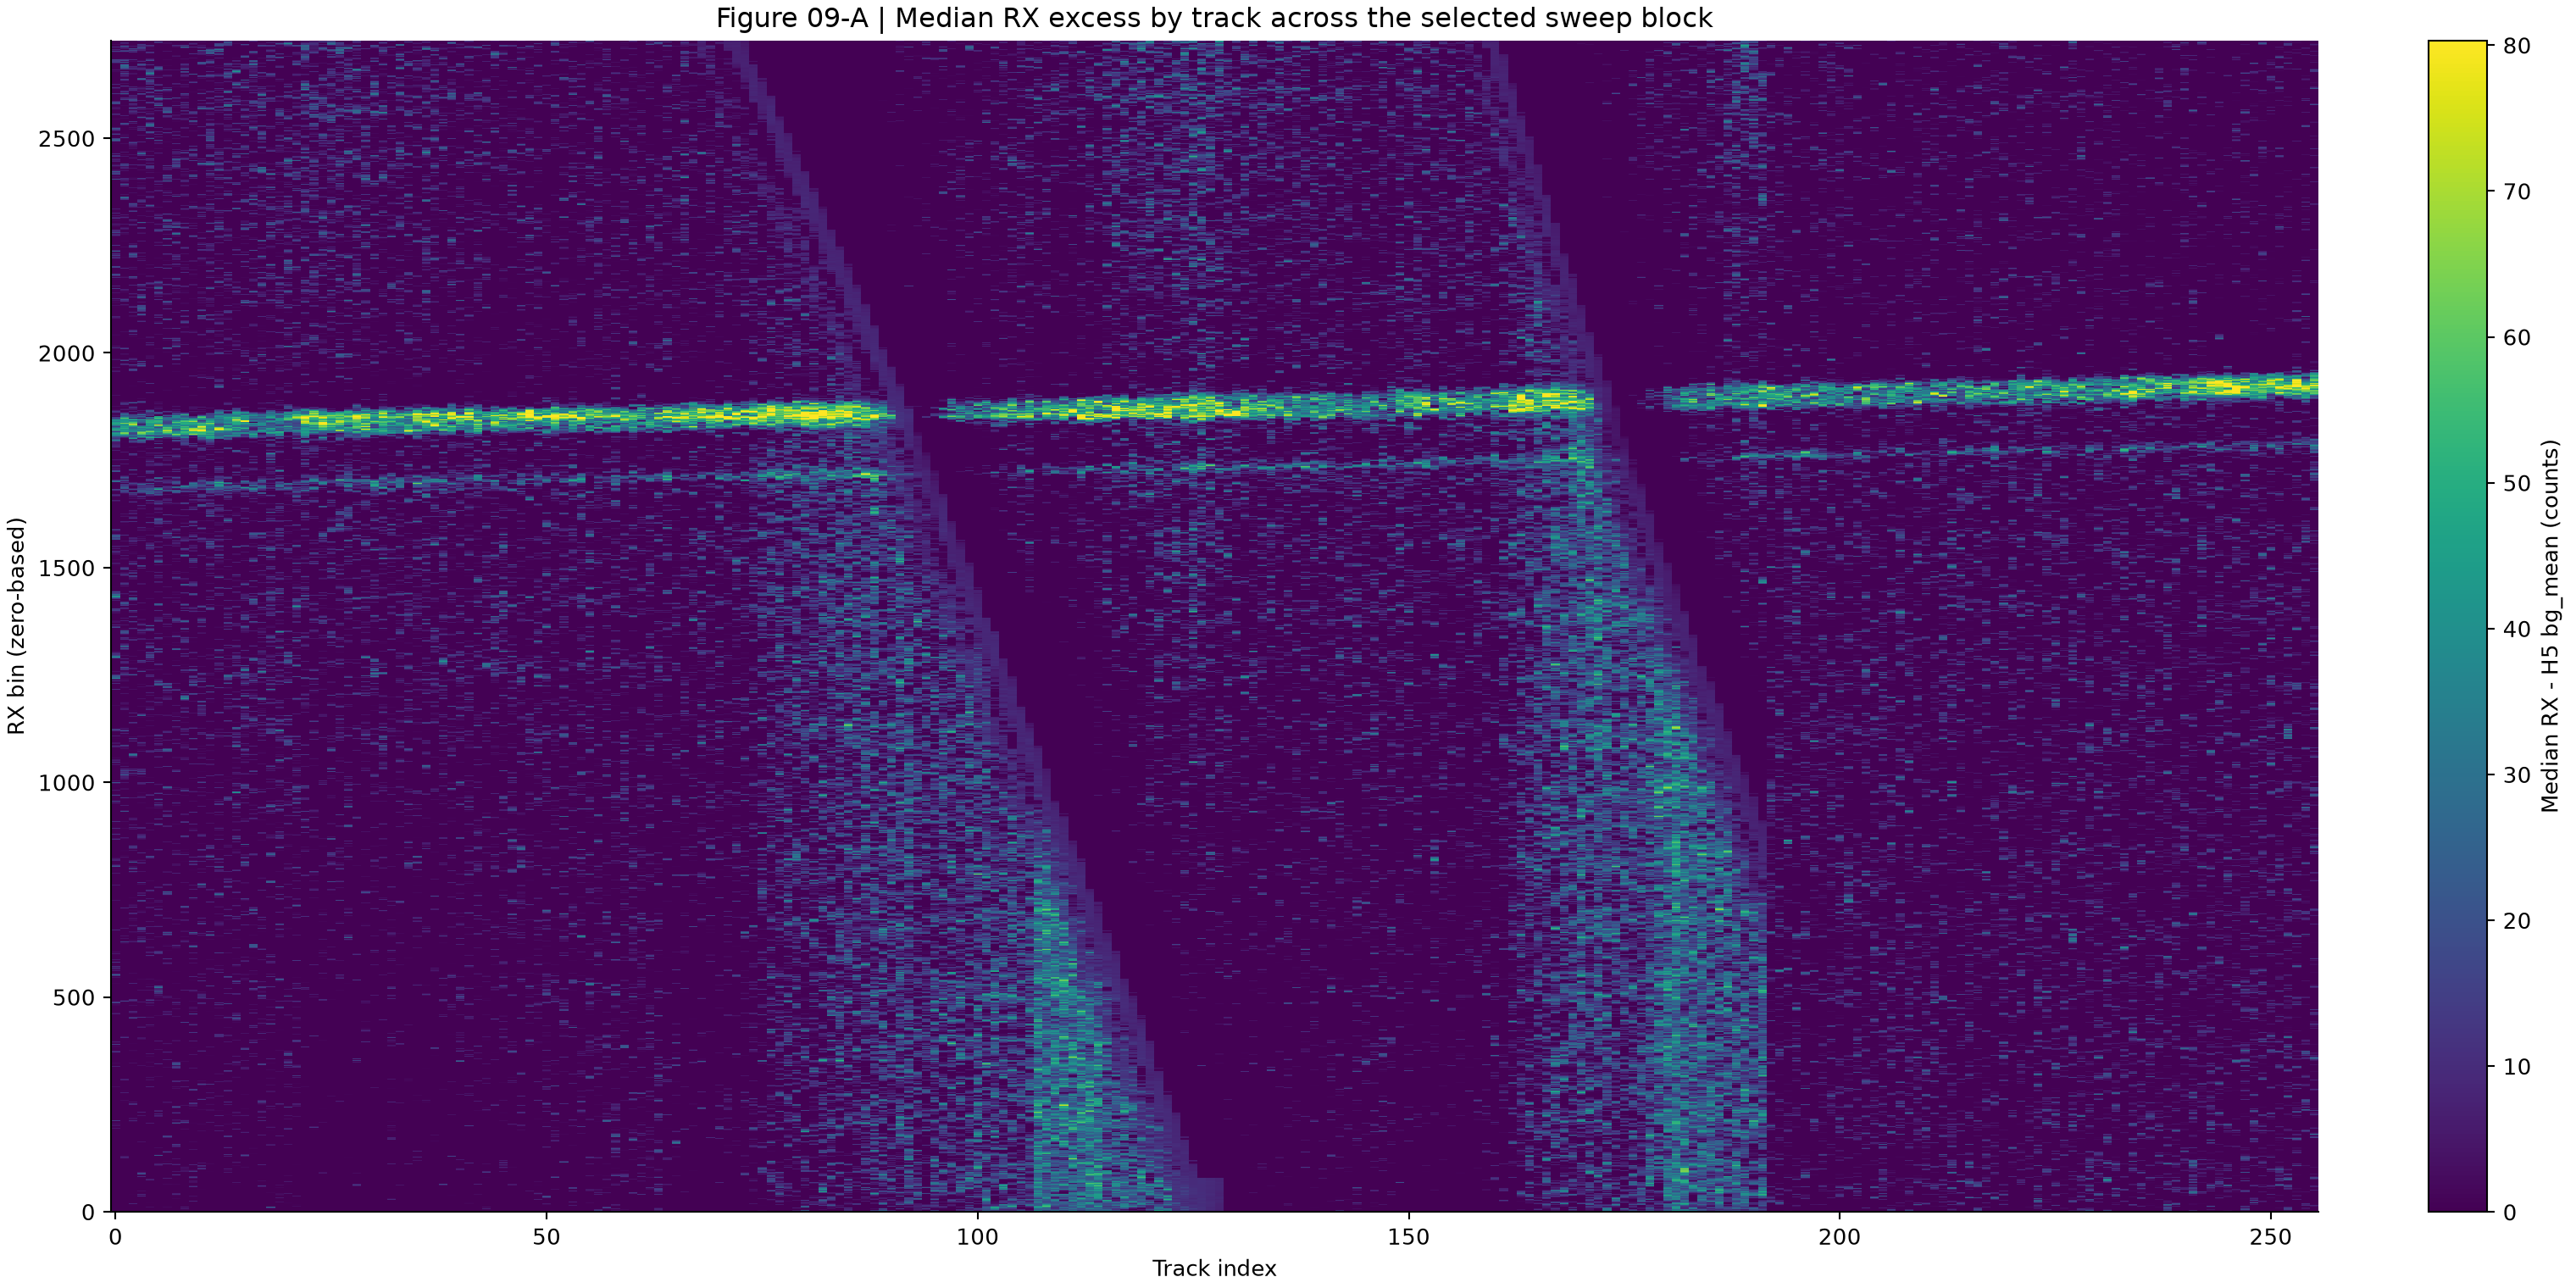

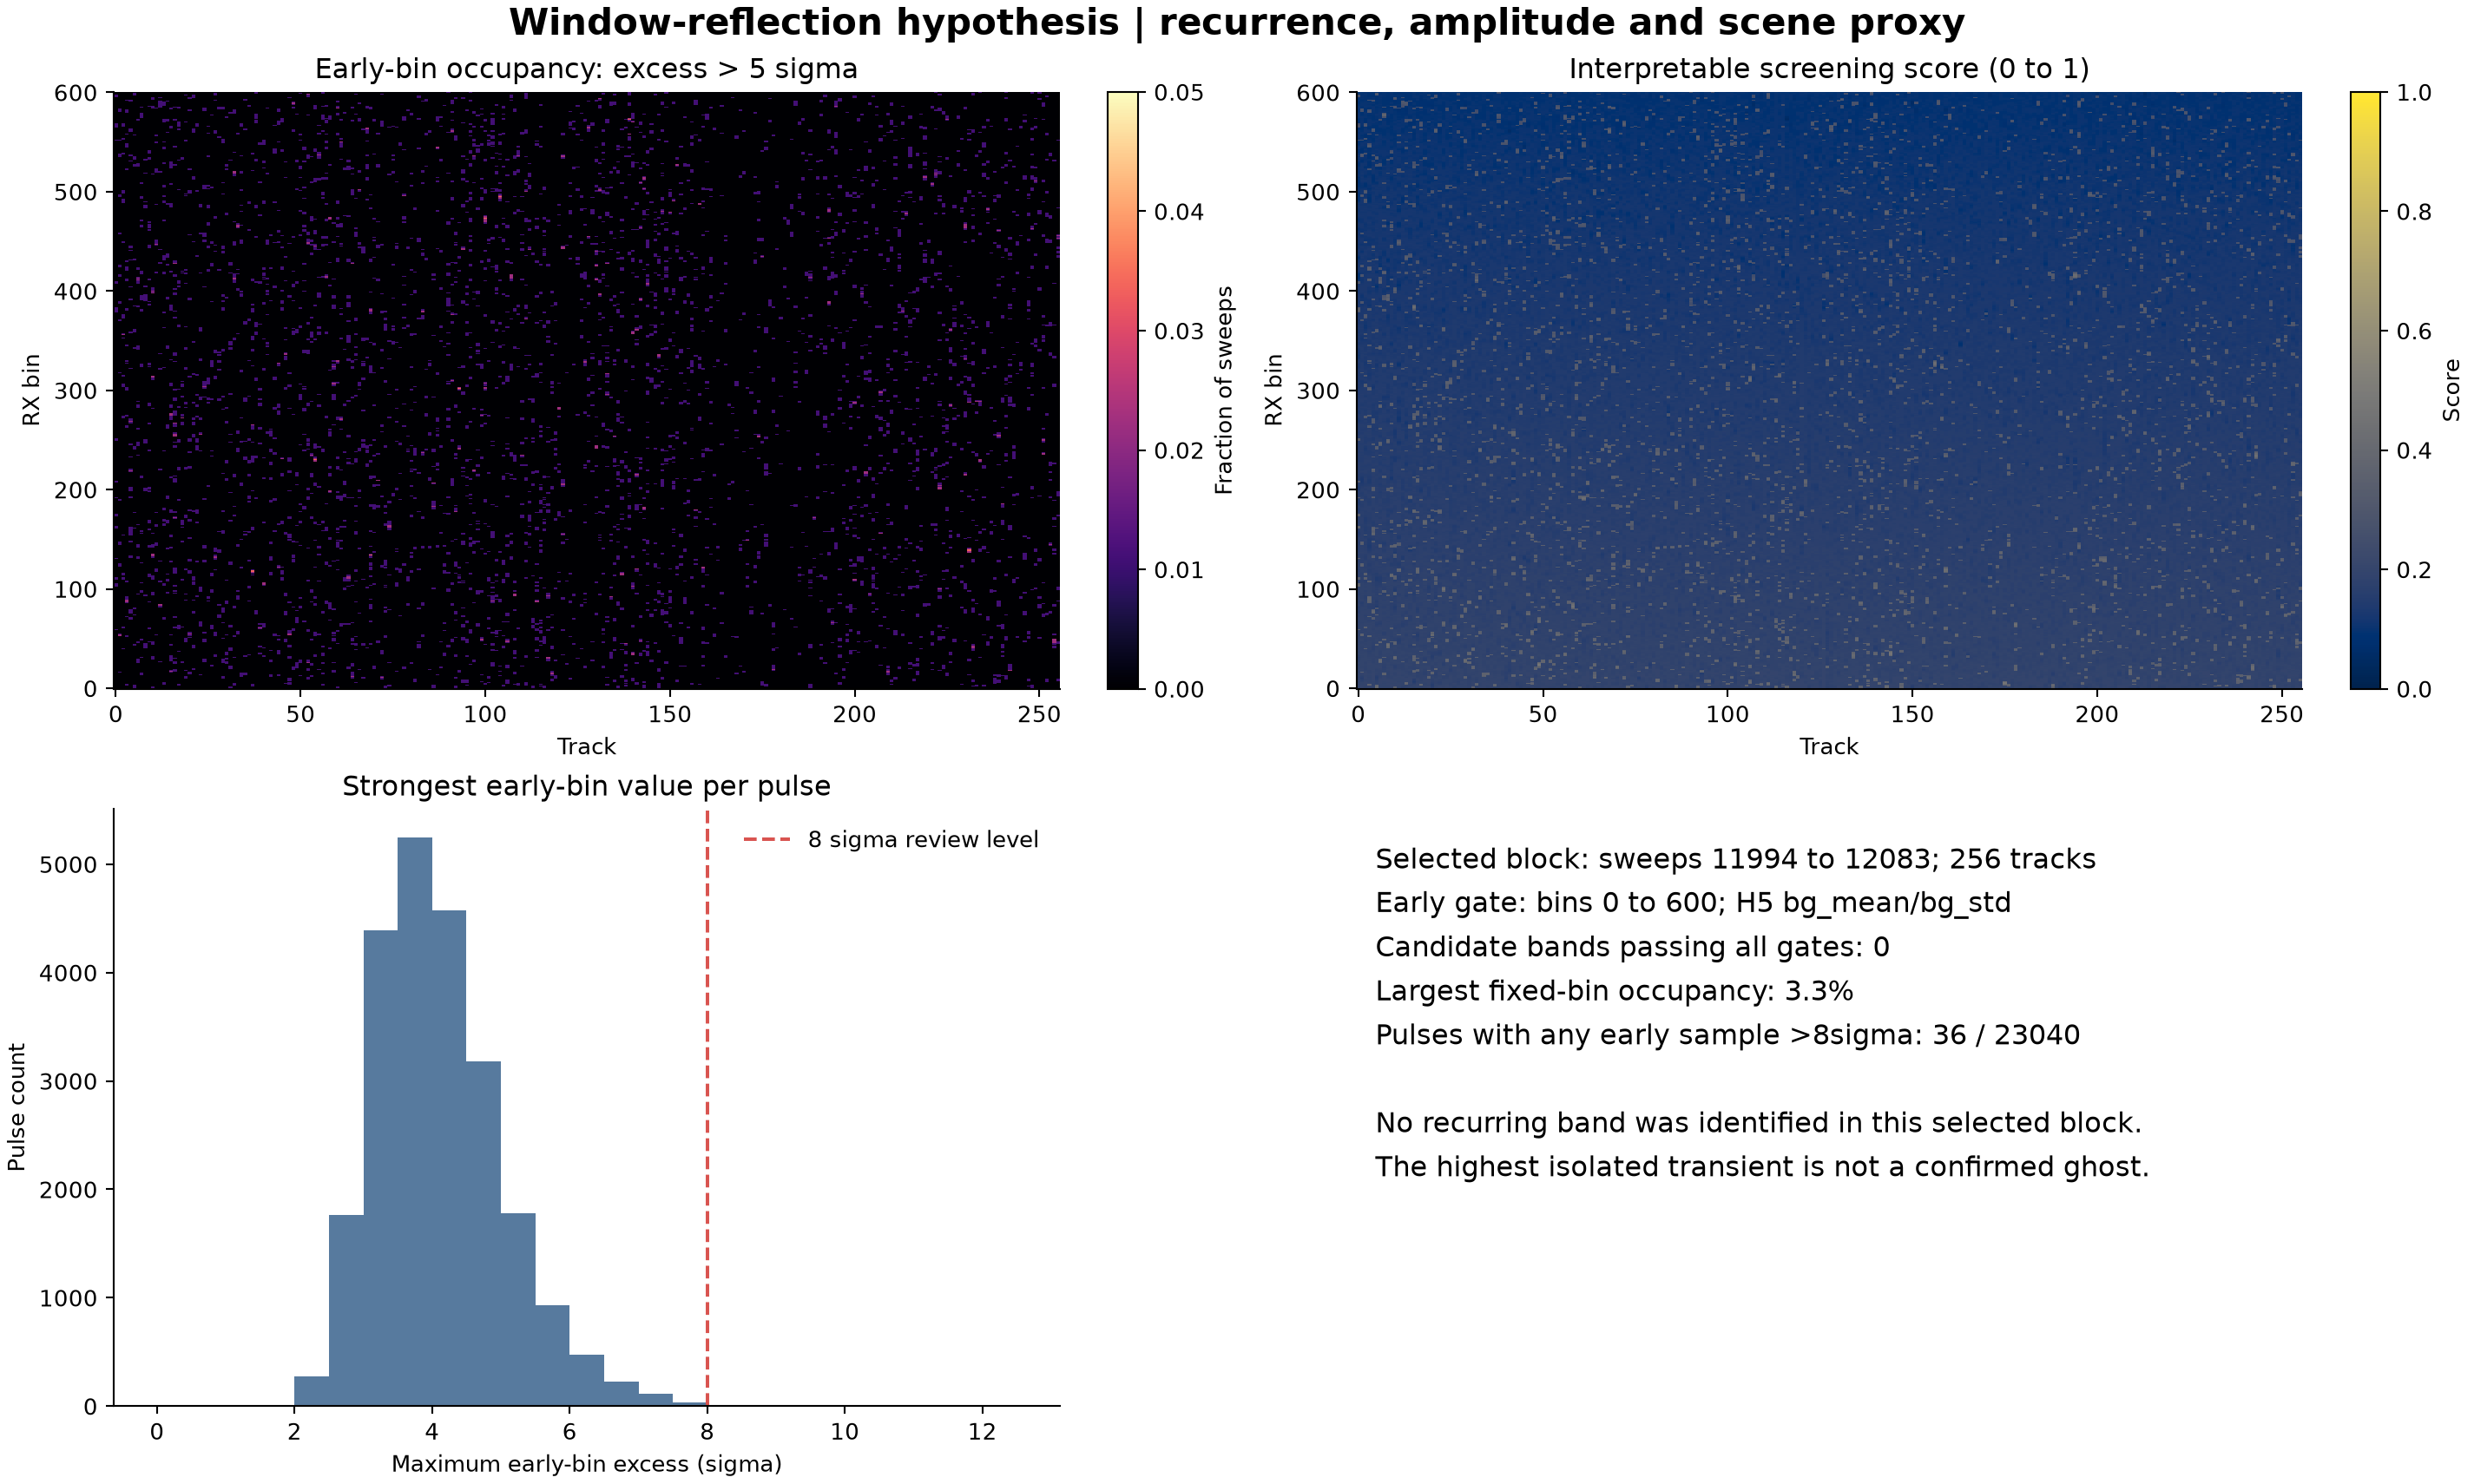

In [4]:
median_excess = np.median(rx_block - scalar["bg_mean"][:, :, None], axis=0)
positive = median_excess[median_excess > 0]
vmax = float(np.percentile(positive, 99.8)) if positive.size else 1.0
fig, ax = plt.subplots(figsize=(16, 8), constrained_layout=True)
im = ax.imshow(np.clip(median_excess.T, 0, vmax), origin="lower", aspect="auto",
               extent=[-0.5, index.n_tracks - 0.5, -0.5, rx_block.shape[2] - 0.5],
               cmap="viridis", vmin=0, vmax=vmax, interpolation="nearest")
for row in candidate_bands.itertuples():
    ax.add_patch(Rectangle((row.track_num - 0.5, row.start_bin - 0.5), 1, row.end_bin - row.start_bin + 1,
                           fill=False, edgecolor="#ee593f", linewidth=1.4))
ax.set(xlabel="Track index", ylabel="RX bin (zero-based)",
       title="Figure 09-A | Median RX excess by track across the selected sweep block")
fig.colorbar(im, ax=ax, label="Median RX - H5 bg_mean (counts)")
fig.savefig(OUTPUT_DIR / "range_track_heatmap.png", dpi=DPI)
plt.close(fig)
display(Image(filename=str(OUTPUT_DIR / "range_track_heatmap.png")))

occ_grid = scores.pivot(index="bin", columns="track_num", values="occupancy").to_numpy()
score_grid = scores.pivot(index="bin", columns="track_num", values="ghost_score").to_numpy()
fig, axes = plt.subplots(2, 2, figsize=(15, 9), constrained_layout=True)
occ_vmax = max(0.05, float(np.nanpercentile(occ_grid, 99.8)))
im0 = axes[0, 0].imshow(occ_grid, origin="lower", aspect="auto", extent=[-0.5, index.n_tracks - 0.5, -0.5, EARLY_BINS - 0.5],
                         cmap="magma", vmin=0, vmax=occ_vmax, interpolation="nearest")
axes[0, 0].set(title=f"Early-bin occupancy: excess > {THRESHOLD_SIGMA:g} sigma", xlabel="Track", ylabel="RX bin")
fig.colorbar(im0, ax=axes[0, 0], label="Fraction of sweeps")
im1 = axes[0, 1].imshow(score_grid, origin="lower", aspect="auto", extent=[-0.5, index.n_tracks - 0.5, -0.5, EARLY_BINS - 0.5],
                         cmap="cividis", vmin=0, vmax=1, interpolation="nearest")
axes[0, 1].set(title="Interpretable screening score (0 to 1)", xlabel="Track", ylabel="RX bin")
fig.colorbar(im1, ax=axes[0, 1], label="Score")
axes[1, 0].hist(early_peak_z.ravel(), bins=np.arange(0, max(13, int(np.nanmax(early_peak_z)) + 2), 0.5), color="#577a9e")
axes[1, 0].axvline(8, color="#d9534f", ls="--", label="8 sigma review level")
axes[1, 0].set(title="Strongest early-bin value per pulse", xlabel="Maximum early-bin excess (sigma)", ylabel="Pulse count")
axes[1, 0].legend(frameon=False)
axes[1, 1].axis("off")
axes[1, 1].text(0.02, 0.95,
    f"Selected block: sweeps {START_SWEEP} to {STOP_SWEEP-1}; {index.n_tracks} tracks\n"
    f"Early gate: bins 0 to {EARLY_BINS-1}; H5 bg_mean/bg_std\n"
    f"Candidate bands passing all gates: {len(candidate_bands)}\n"
    f"Largest fixed-bin occupancy: {scores.occupancy.max():.1%}\n"
    f"Pulses with any early sample >8sigma: {(early_peak_z > 8).sum()} / {early_peak_z.size}\n\n"
    + ("No recurring band was identified in this selected block.\nThe highest isolated transient is not a confirmed ghost."
       if candidate_bands.empty else "Bands require human review; a fixed-bin band does not prove an optical reflection."),
    va="top", fontsize=12, linespacing=1.6)
fig.suptitle("Window-reflection hypothesis | recurrence, amplitude and scene proxy", fontsize=16, fontweight="bold")
fig.savefig(OUTPUT_DIR / "window_reflection_overview.png", dpi=DPI)
plt.close(fig)
display(Image(filename=str(OUTPUT_DIR / "window_reflection_overview.png")))

## Figure 09-B | Track-localized examples

The screening pulse's track, the Notebook 06 road-context track, and the canopy-context track provide a strong transient view plus local controls. Each panel shows RX excess normalized by the H5 background standard deviation, with the raw-maximum bin trajectory overlaid. A separate three-track figure plots raw early-window waveforms from the event sweep for local comparison. `Refh` and the candidate score are diagnostics; neither labels the scene nor confirms an instrument cause.

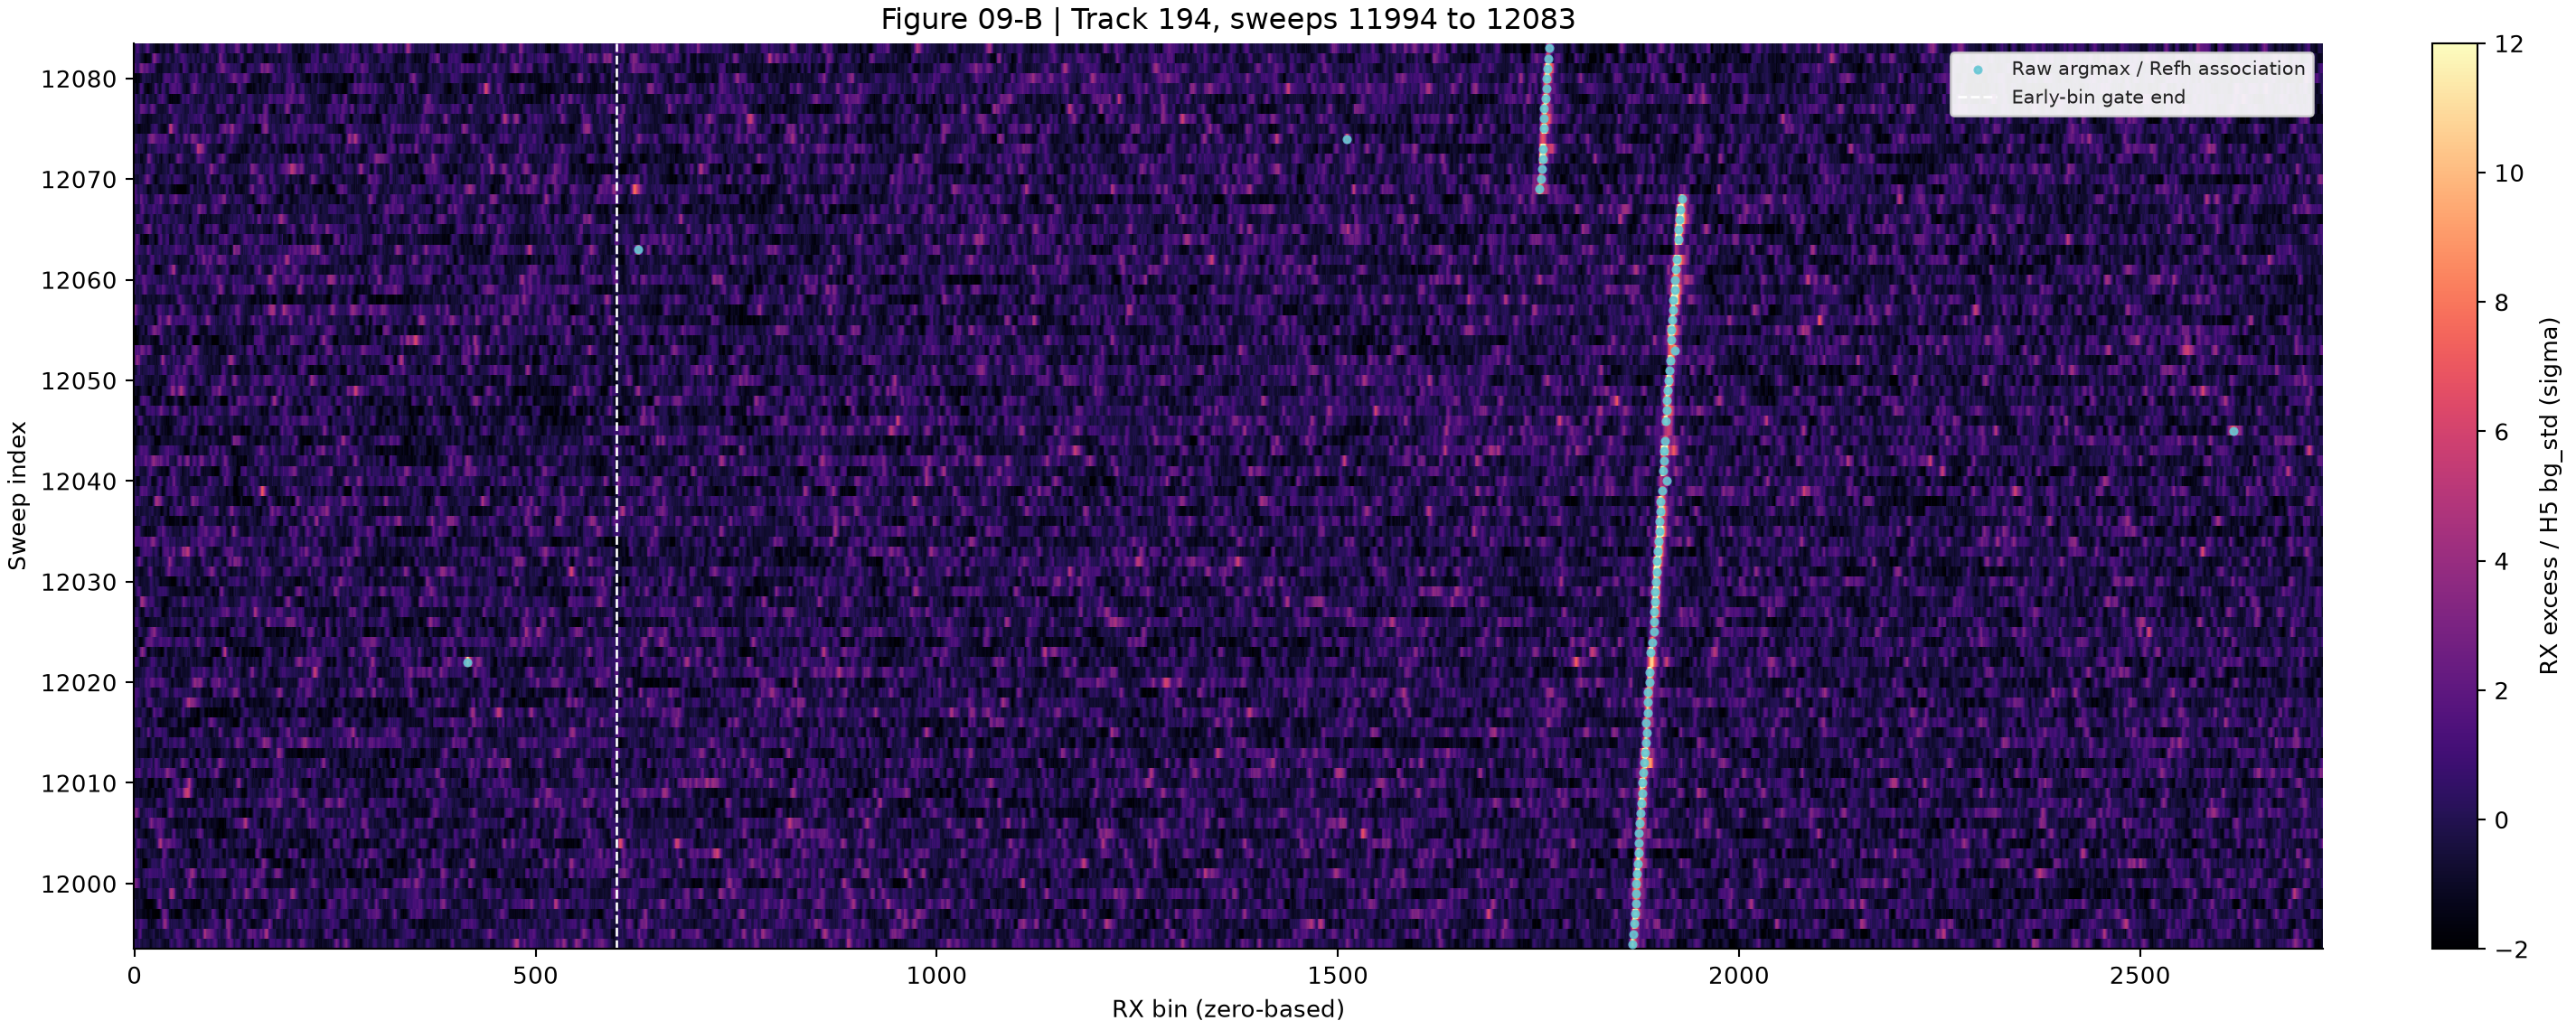

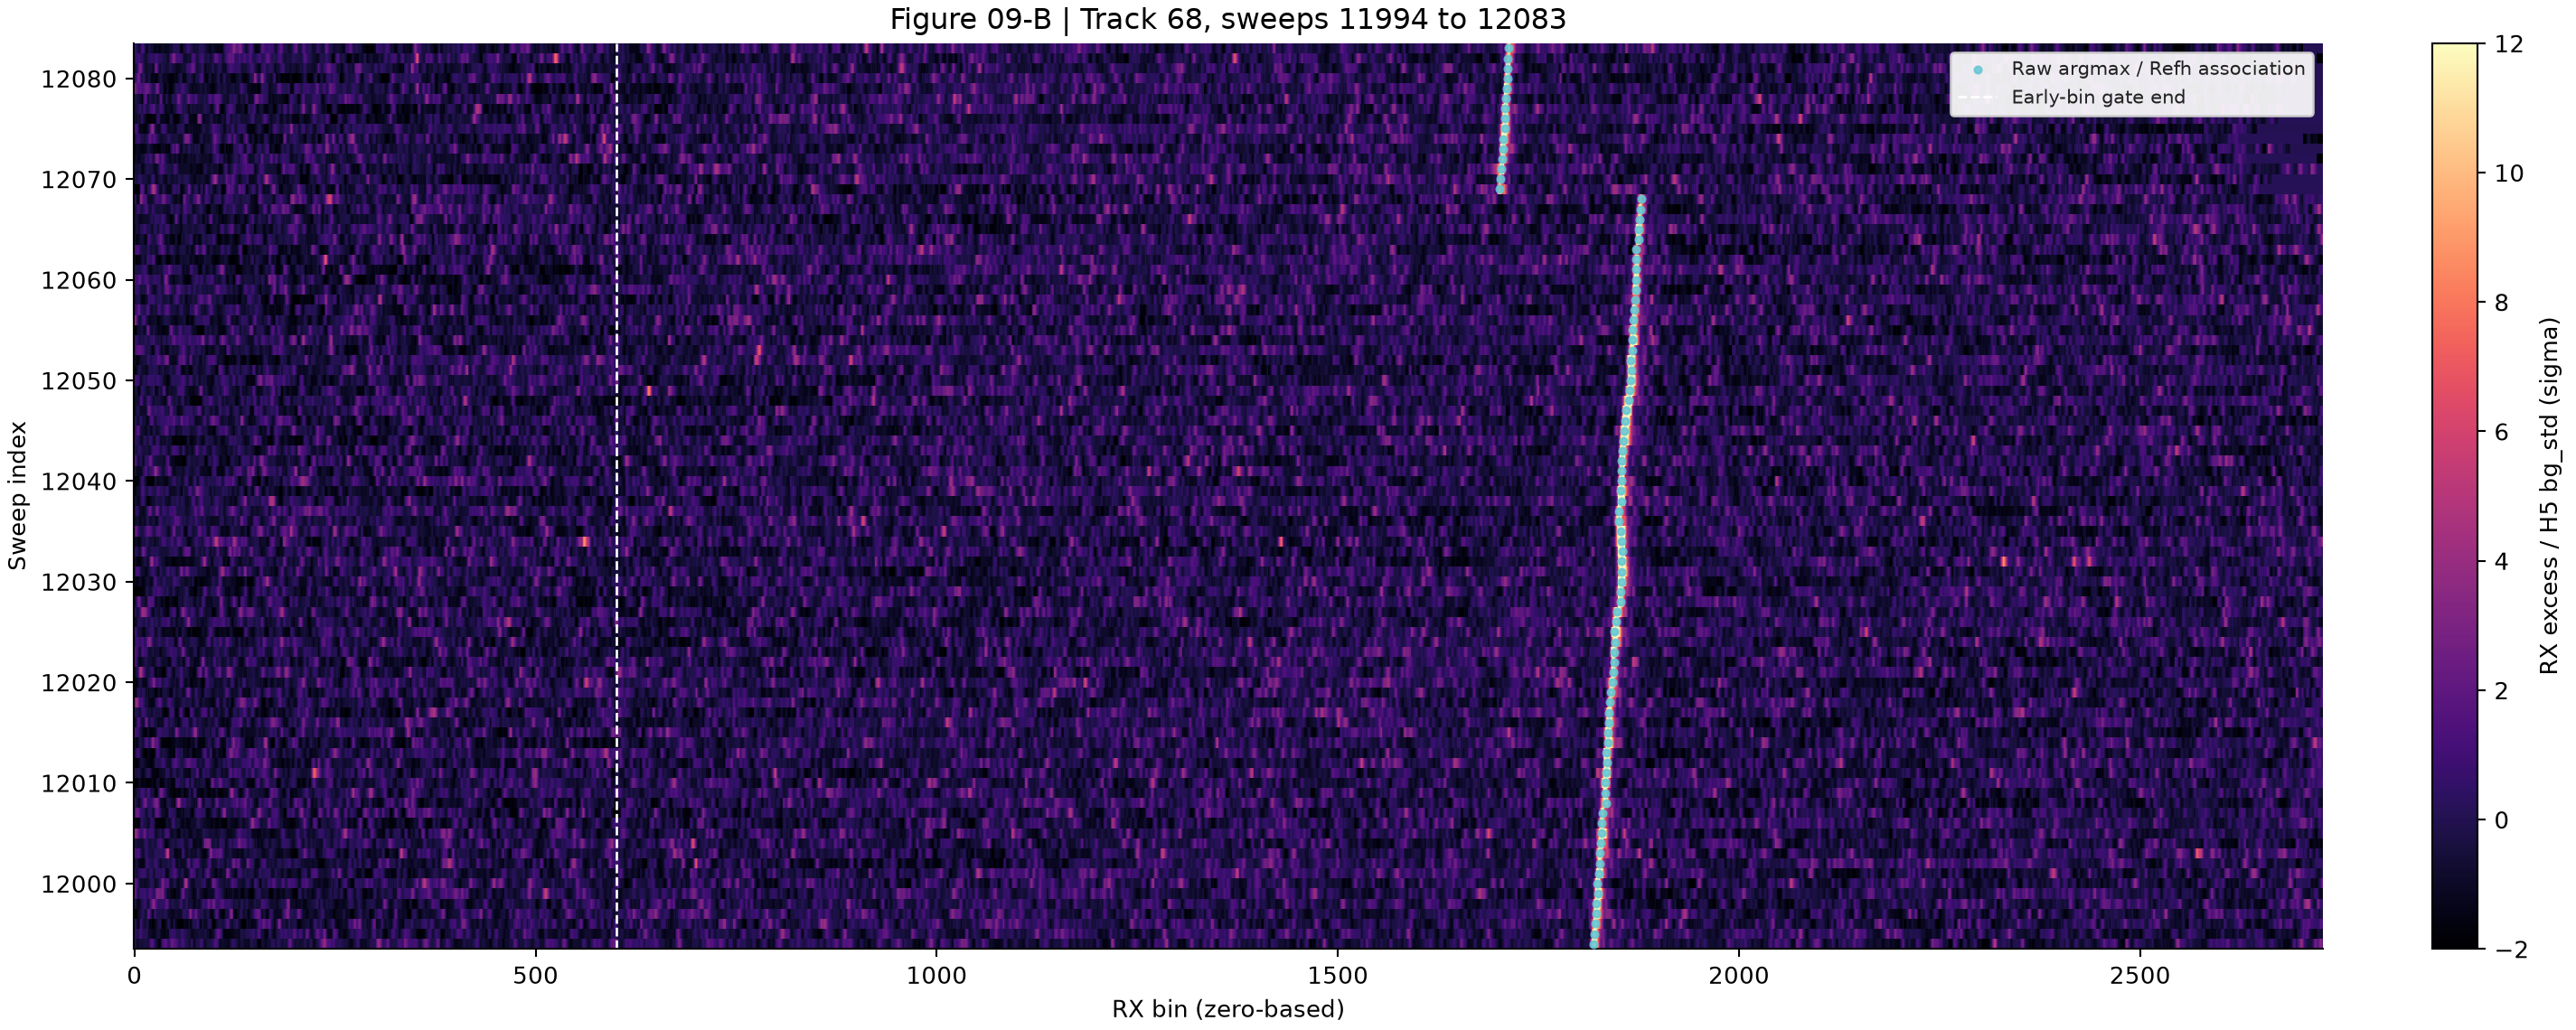

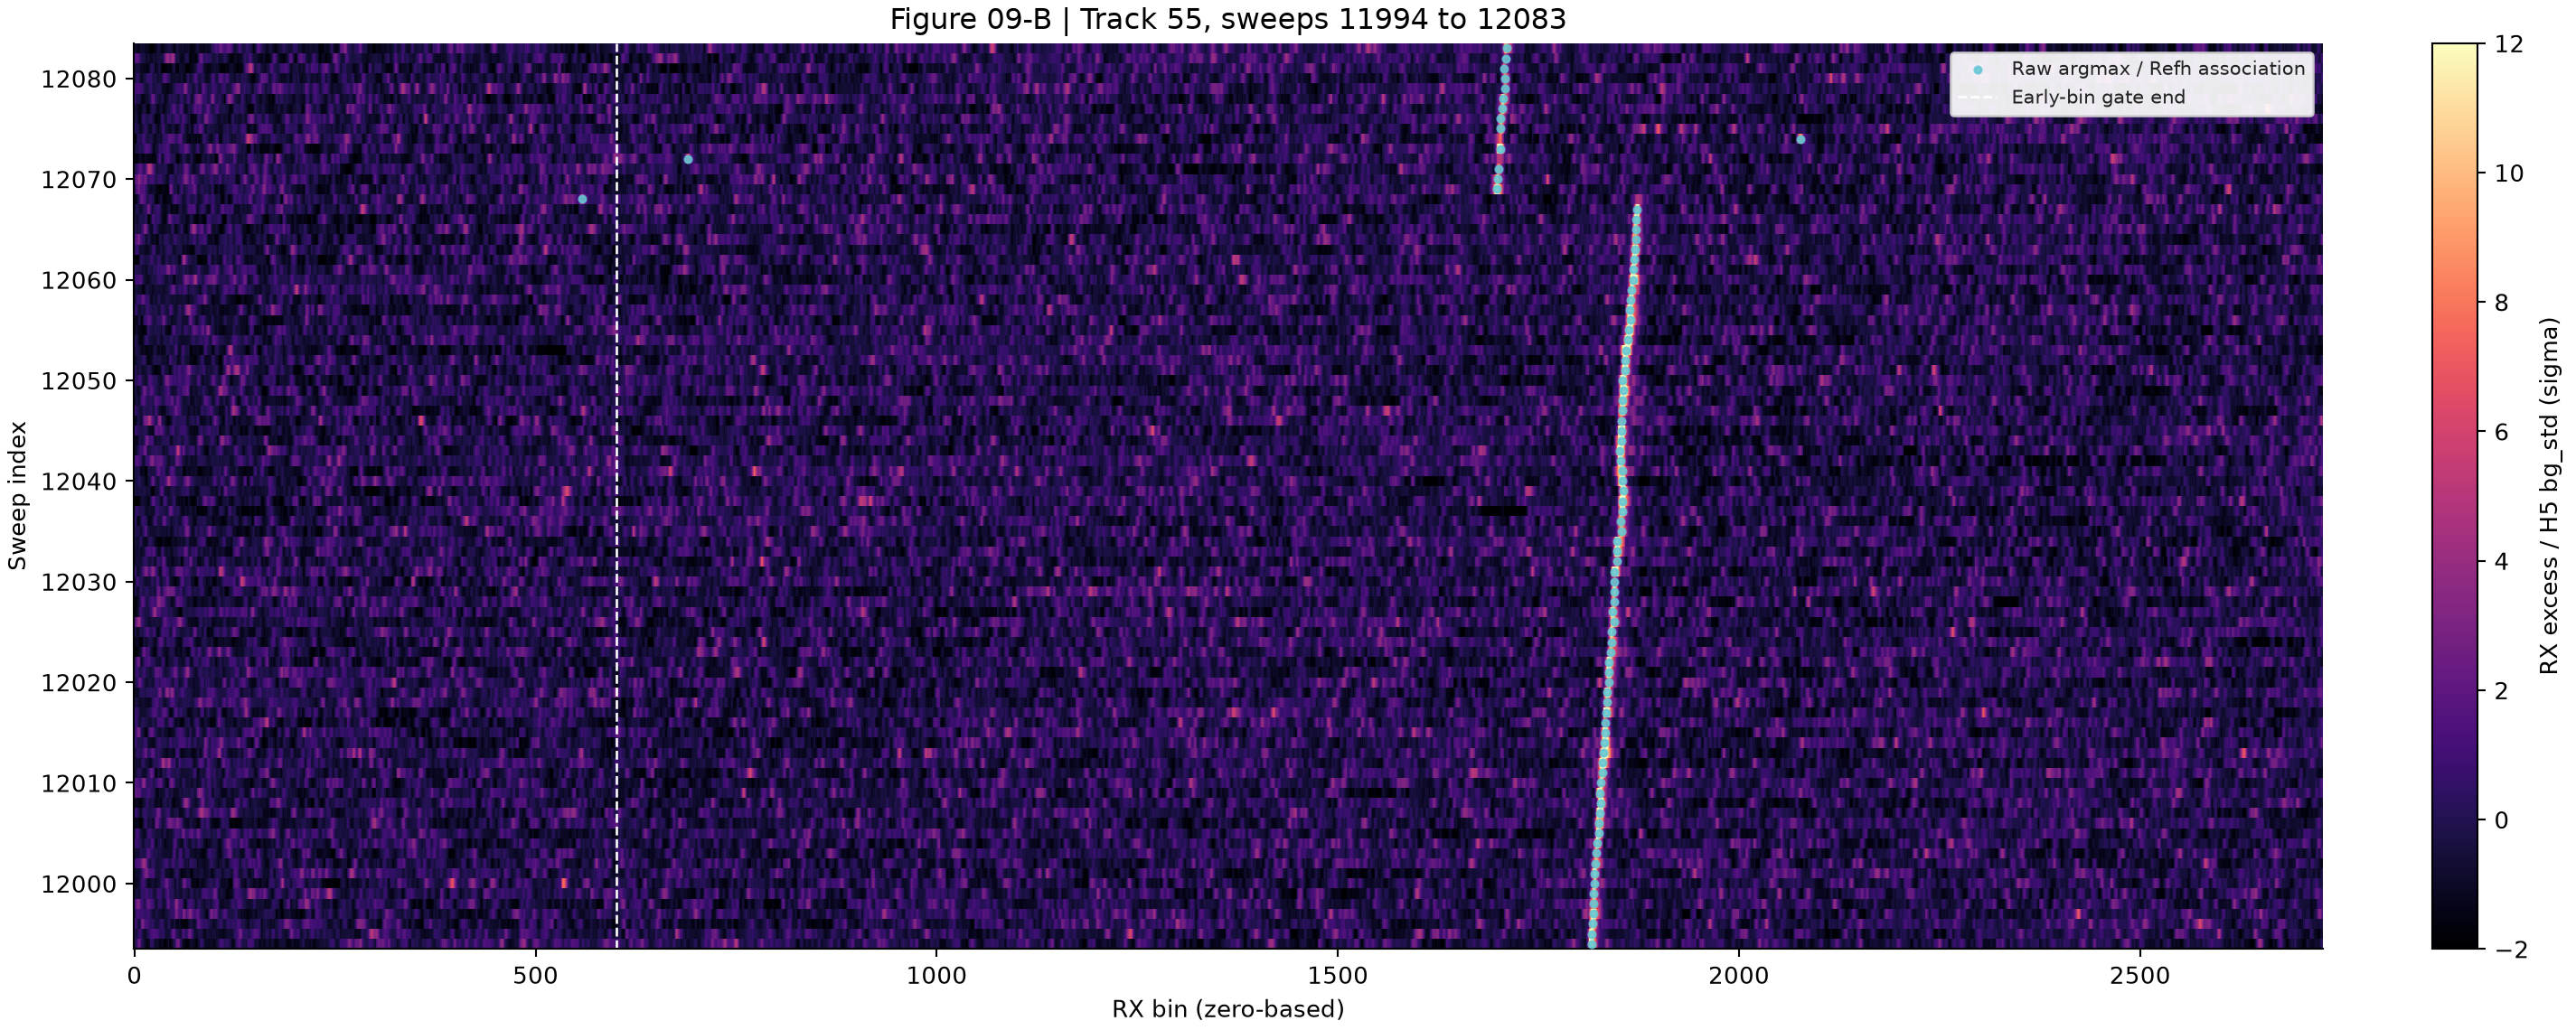

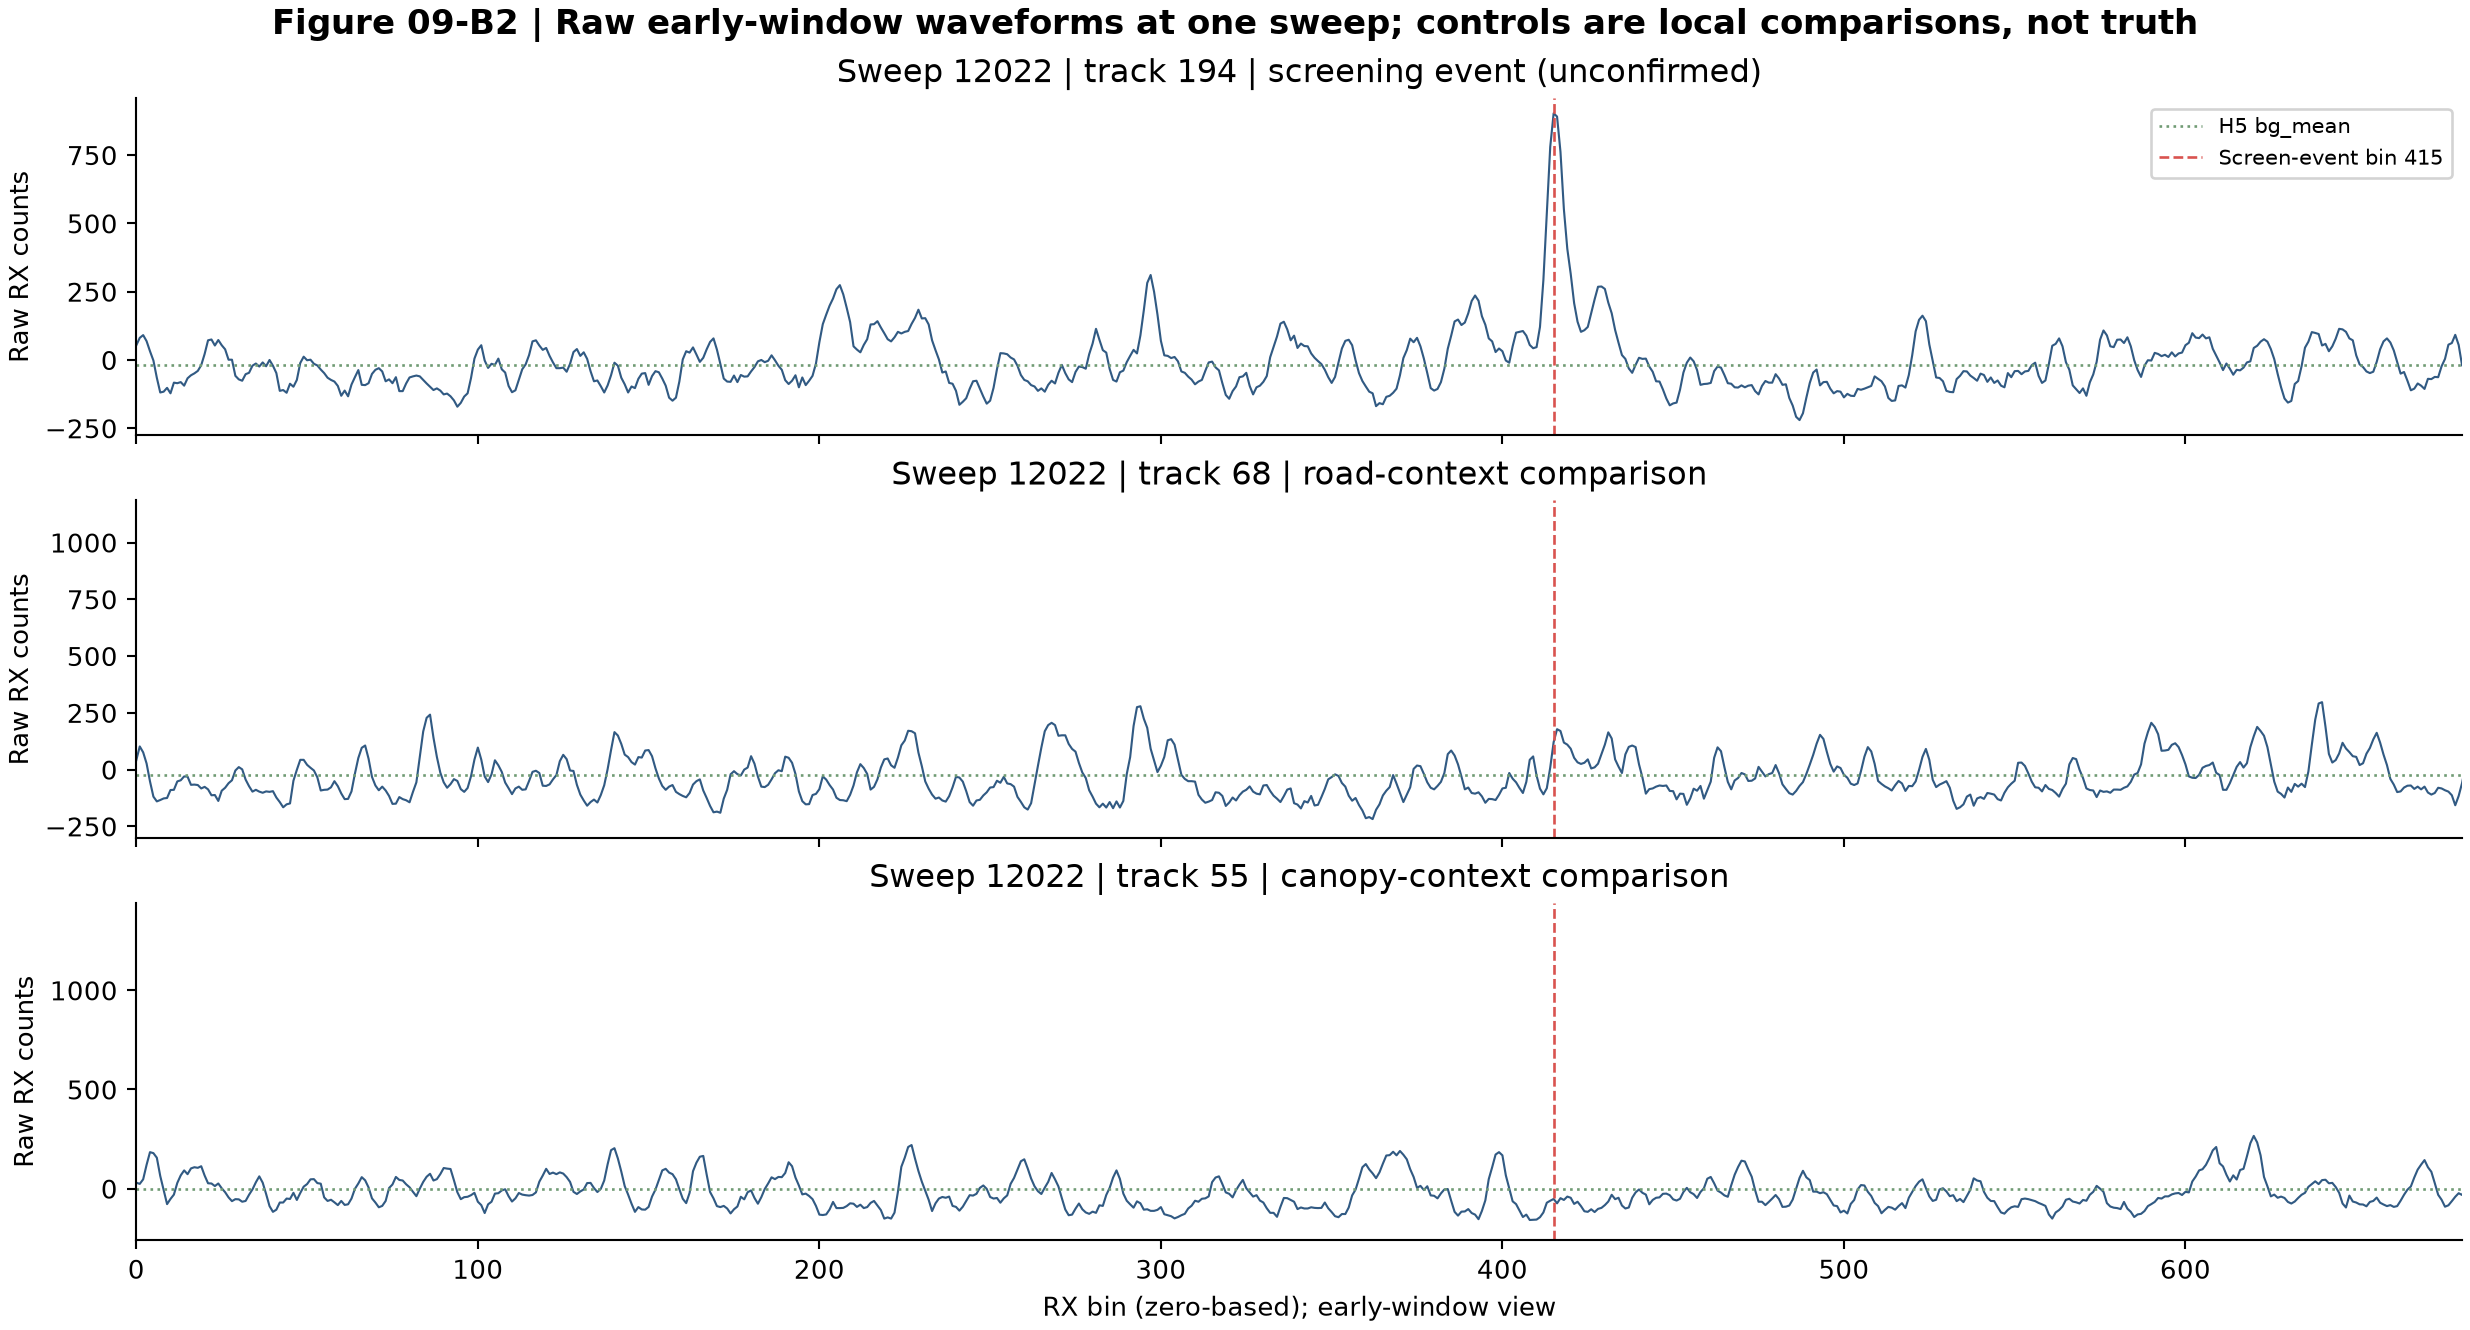

In [5]:
screen_track = int(screen["track_num"])
tracks_to_show = list(dict.fromkeys([screen_track, 68, 55] + candidate_bands.track_num.astype(int).tolist()))[:4]
for track in tracks_to_show:
    excess_sigma = (rx_block[:, track, :] - scalar["bg_mean"][:, track, None]) / np.maximum(scalar["bg_std"][:, track, None], 1e-6)
    fig, ax = plt.subplots(figsize=(15, 6), constrained_layout=True)
    im = ax.imshow(np.clip(excess_sigma, -2, 12), origin="lower", aspect="auto",
                   extent=[-0.5, rx_block.shape[2] - 0.5, START_SWEEP - 0.5, STOP_SWEEP - 0.5],
                   cmap="magma", vmin=-2, vmax=12, interpolation="nearest")
    track_offsets = np.arange(STOP_SWEEP - START_SWEEP)
    ax.scatter(raw_argmax[:, track], START_SWEEP + track_offsets, color="#65c6d4", s=8, alpha=0.85,
               label="Raw argmax / Refh association", zorder=3)
    ax.axvline(EARLY_BINS, color="white", ls="--", lw=1.0, label="Early-bin gate end")
    for row in candidate_bands[candidate_bands.track_num == track].itertuples():
        ax.add_patch(Rectangle((row.start_bin - 0.5, START_SWEEP - 0.5), row.end_bin - row.start_bin + 1,
                               STOP_SWEEP - START_SWEEP, fill=False, edgecolor="#59ef82", linewidth=1.5))
    ax.set(xlabel="RX bin (zero-based)", ylabel="Sweep index", title=f"Figure 09-B | Track {track}, sweeps {START_SWEEP} to {STOP_SWEEP-1}")
    ax.legend(loc="upper right", frameon=True, facecolor="white", edgecolor="#d0d0d0", framealpha=0.92, labelcolor="#222222", fontsize=8)
    fig.colorbar(im, ax=ax, label="RX excess / H5 bg_std (sigma)")
    path = OUTPUT_DIR / f"track_sweep_heatmap_{track}.png"
    fig.savefig(path, dpi=DPI)
    plt.close(fig)
    display(Image(filename=str(path)))

# Compare the selected transient with two local track controls at the same sweep.
sample_sweep = int(screen["sweep_num"])
sample_offset = sample_sweep - START_SWEEP
waveform_roles = {screen_track: "screening event (unconfirmed)", 68: "road-context comparison", 55: "canopy-context comparison"}
waveform_tracks = list(dict.fromkeys([screen_track, 68, 55]))
fig, axes = plt.subplots(len(waveform_tracks), 1, figsize=(13, 7), sharex=True, constrained_layout=True)
axes = np.atleast_1d(axes)
for ax, track in zip(axes, waveform_tracks):
    ax.plot(np.arange(rx_block.shape[2]), rx_block[sample_offset, track], color="#315a83", lw=0.8)
    ax.axhline(float(scalar["bg_mean"][sample_offset, track]), color="#709b74", ls=":", lw=1.0, label="H5 bg_mean")
    ax.axvline(float(screen["early_peak_bin"]), color="#d9534f", ls="--", lw=1.0,
               label=f"Screen-event bin {int(screen['early_peak_bin'])}")
    ax.set(ylabel="Raw RX counts", title=f"Sweep {sample_sweep} | track {track} | {waveform_roles.get(track, 'local comparison')}")
    ax.set_xlim(0, min(rx_block.shape[2] - 1, EARLY_BINS + 80))
axes[0].legend(loc="upper right", frameon=True, facecolor="white", edgecolor="#d0d0d0", framealpha=0.92, fontsize=8)
axes[-1].set_xlabel("RX bin (zero-based); early-window view")
fig.suptitle("Figure 09-B2 | Raw early-window waveforms at one sweep; controls are local comparisons, not truth", fontsize=13, fontweight="bold")
fig.savefig(OUTPUT_DIR / "representative_waveforms.png", dpi=DPI)
plt.close(fig)
display(Image(filename=str(OUTPUT_DIR / "representative_waveforms.png")))

## Strategy comparison on the selected screening pulse

**A: Flag only** is the default when a band is supported. **B: Mask bins** can be used for decomposition or peak interpretation. **C: Template subtraction** is an exploratory display only because a template can remove real scene energy. If this block has no candidate band, no bins are flagged, masked, or subtracted; the board records that null before/after outcome instead of inventing a correction.

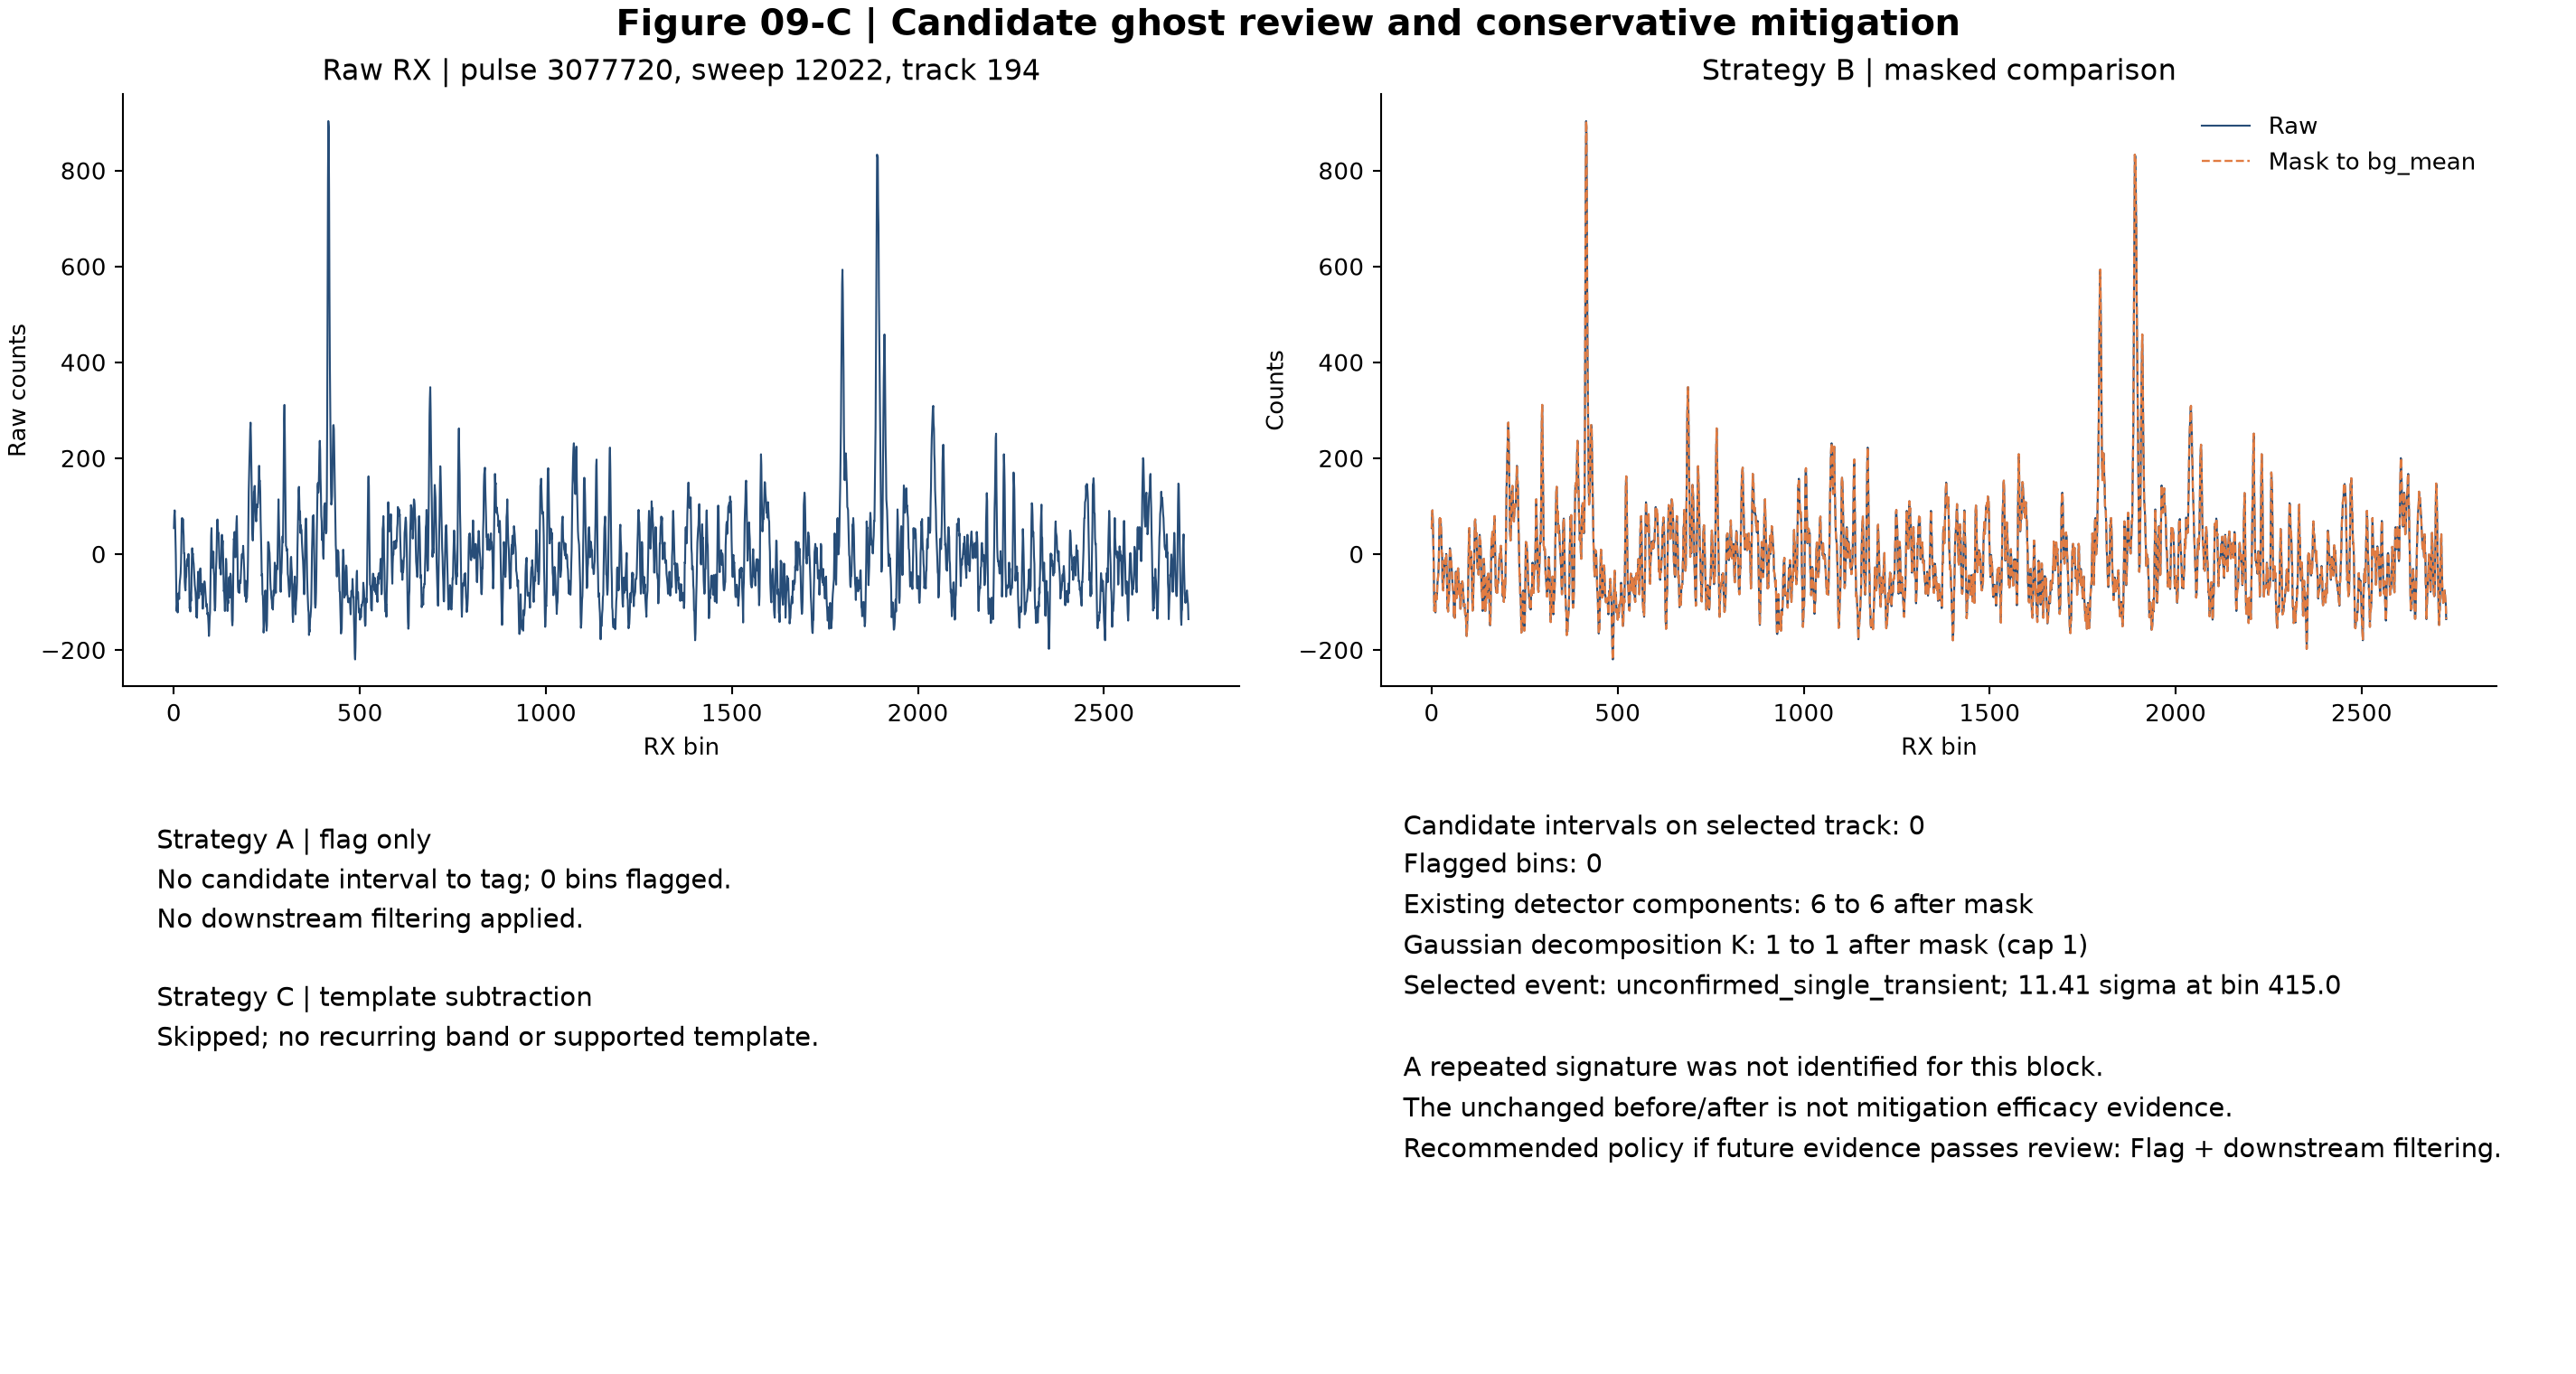

{'pulse_index': 3077720, 'sweep_num': 12022, 'track_num': 194, 'early_peak_bin': 415, 'early_peak_sigma': 11.407564375792198, 'candidate_intervals': [], 'flagged_bins': 0, 'fit_component_cap': 1, 'detector_components_before': 6, 'detector_components_after_mask': 6, 'detector_components_after_template': None, 'decomposition_k_before': 1, 'decomposition_k_after_mask': 1, 'template_applied': False, 'interpretation': 'No correction or mitigation was applied because no candidate band was supported.'}


In [6]:
pulse = int(screen["pulse_index"])
sweep = int(screen["sweep_num"])
track = int(screen["track_num"])
sweep_offset = sweep - START_SWEEP
track_offset = track
wave = rx_block[sweep_offset, track_offset].astype(float)
bg_mean = float(scalar["bg_mean"][sweep_offset, track_offset])
bg_std = float(scalar["bg_std"][sweep_offset, track_offset])
refh_thres = float(scalar["refh_thres"][sweep_offset, track_offset])
track_bands = candidate_bands[candidate_bands.track_num == track]
intervals = [{"start_bin": int(row.start_bin), "end_bin": int(row.end_bin)} for row in track_bands.itertuples()]
flags = flag_bins(wave.size, intervals)
masked = mask_bins(wave, intervals)
masked_for_analysis = wave.copy() if not intervals else np.where(np.isfinite(masked), masked, bg_mean)
if candidate_bands.empty:
    assert intervals == [] and int(flags.sum()) == 0
    np.testing.assert_array_equal(masked, wave)
    assert np.array_equal(masked_for_analysis, wave, equal_nan=True)

template = None
subtracted = None
if intervals:
    template = np.zeros(wave.size, dtype=float)
    for interval in intervals:
        lo, hi = interval["start_bin"], interval["end_bin"]
        local = rx_block[:, track, lo : hi + 1] - scalar["bg_mean"][:, track, None]
        template[lo : hi + 1] = np.nanmedian(local, axis=0)
    subtracted = bg_mean + subtract_template(wave - bg_mean, template)
if candidate_bands.empty:
    assert template is None and subtracted is None

config_path = ROOT / "outputs/notebooks/06_waveform_gallery/scientific_review" / H5_PATH.stem / "selected_waveform_cases.json"
if config_path.is_file():
    detector_config = json.loads(config_path.read_text(encoding="utf-8"))["detector_config"]
    detector_config_source = str(config_path.relative_to(ROOT))
else:
    detector_config = build_detector_config(default_config([H5_PATH], OUTPUT_DIR))
    detector_config_source = "current package default detector configuration"

def detect(y):
    return detect_candidate_components_1d(y, bg_mean, bg_std, refh_thres, detector_config)

components_before = detect(wave)
components_masked = detect(masked_for_analysis)
components_subtracted = detect(subtracted) if subtracted is not None else None
baseline_info = estimate_baseline(wave, bg_mean, bg_std)
fit_component_cap = 5 if float(scalar["refh_snr"][sweep_offset, track_offset]) >= 5.0 else 1
fit_before = fit_gaussian_components(wave, baseline_info["baseline"], baseline_info["noise_sigma"],
                                     components_before, max_components=fit_component_cap)
fit_masked = fit_gaussian_components(masked_for_analysis, baseline_info["baseline"], baseline_info["noise_sigma"],
                                     components_masked, max_components=fit_component_cap)

fig, axes = plt.subplots(2, 2, figsize=(15, 8), constrained_layout=True)
bins = np.arange(wave.size)
axes[0, 0].plot(bins, wave, color="#274d78", lw=0.8)
for item in intervals:
    axes[0, 0].axvspan(item["start_bin"], item["end_bin"], color="#e94f37", alpha=0.2)
axes[0, 0].set(title=f"Raw RX | pulse {pulse}, sweep {sweep}, track {track}", xlabel="RX bin", ylabel="Raw counts")
axes[0, 1].plot(bins, wave, color="#274d78", lw=0.8, label="Raw")
axes[0, 1].plot(bins, masked_for_analysis, color="#e17c42", lw=0.9, ls="--", label="Mask to bg_mean")
axes[0, 1].set(title="Strategy B | masked comparison", xlabel="RX bin", ylabel="Counts")
axes[0, 1].legend(frameon=False)
if subtracted is None:
    axes[1, 0].axis("off")
    axes[1, 0].text(0.03, 0.92, "Strategy A | flag only\nNo candidate interval to tag; 0 bins flagged.\nNo downstream filtering applied.\n\nStrategy C | template subtraction\nSkipped; no recurring band or supported template.", va="top", fontsize=11, linespacing=1.5)
else:
    axes[1, 0].plot(bins, wave, color="#274d78", lw=0.8, label="Raw")
    axes[1, 0].plot(bins, subtracted, color="#a34b6b", lw=0.8, label="Exploratory template-subtracted")
    axes[1, 0].set(title="Strategy C | exploratory only", xlabel="RX bin", ylabel="Counts")
    axes[1, 0].legend(frameon=False)
axes[1, 1].axis("off")
axes[1, 1].text(0.02, 0.95,
    f"Candidate intervals on selected track: {len(intervals)}\n"
    f"Flagged bins: {int(flags.sum())}\n"
    f"Existing detector components: {len(components_before)} to {len(components_masked)} after mask\n"
    f"Gaussian decomposition K: {fit_before['chosen_k']} to {fit_masked['chosen_k']} after mask (cap {fit_component_cap})\n"
    f"Selected event: {screen_status}; {screen['early_peak_sigma']:.2f} sigma at bin {screen['early_peak_bin']}\n\n"
    "A repeated signature was not identified for this block.\nThe unchanged before/after is not mitigation efficacy evidence.\n"
    "Recommended policy if future evidence passes review: Flag + downstream filtering.",
    va="top", fontsize=11, linespacing=1.55)
fig.suptitle("Figure 09-C | Candidate ghost review and conservative mitigation", fontsize=15, fontweight="bold")
fig.savefig(OUTPUT_DIR / "ghost_filter_examples.png", dpi=DPI)
plt.close(fig)
display(Image(filename=str(OUTPUT_DIR / "ghost_filter_examples.png")))

comparison = {
    "pulse_index": pulse, "sweep_num": sweep, "track_num": track,
    "early_peak_bin": int(screen["early_peak_bin"]), "early_peak_sigma": float(screen["early_peak_sigma"]),
    "candidate_intervals": intervals, "flagged_bins": int(flags.sum()),
    "fit_component_cap": int(fit_component_cap),
    "detector_components_before": len(components_before), "detector_components_after_mask": len(components_masked),
    "detector_components_after_template": None if components_subtracted is None else len(components_subtracted),
    "decomposition_k_before": int(fit_before["chosen_k"]), "decomposition_k_after_mask": int(fit_masked["chosen_k"]),
    "template_applied": subtracted is not None,
    "interpretation": "No correction or mitigation was applied because no candidate band was supported." if not intervals else "Candidate mitigation is diagnostic and requires human review.",
}
print(comparison)

## Figure 09-C | Candidate ghost summary and reproducibility

An empty candidate table means no fixed-bin track interval in this bounded sample met the stated recurrence, amplitude, and score gates. The strongest isolated early event remains an unconfirmed transient. An isolated event cannot establish track localization, persistence, or an optical-window mechanism.

In [7]:
top_track_ranges = []
for track in range(index.n_tracks):
    heights = scalar["refh"][:, track]
    top_track_ranges.append({
        "track_num": int(track), "refh_p10_m": float(np.nanpercentile(heights, 10)),
        "refh_p90_m": float(np.nanpercentile(heights, 90)), "refh_std_m": float(np.nanstd(heights)),
    })
summary = {
    "h5": str(H5_PATH.relative_to(ROOT)), "granule_stem": H5_PATH.stem,
    "source_attributes": {key: source_attrs.get(key) for key in ["start_utca", "end_utca", "n_pulses", "n_sweeps", "n_tracks", "n_rx_bins"]},
    "selection": block_info,
    "scene_context_by_track": [row for row in top_track_ranges if row["track_num"] in sorted(set([screen_track, 55, 68] + candidate_bands.track_num.astype(int).tolist()))],
    "method": {
        "occupancy_denominator": "finite sweeps at each track/bin; valid_sweep_count is exposed in the score table",
        "thresholds_are_heuristics": True,
        "threshold_sigma": THRESHOLD_SIGMA, "early_bins": EARLY_BINS,
        "occupancy_min": OCCUPANCY_MIN, "median_excess_sigma_min": EXCESS_SIGMA_MIN,
        "score_min": SCORE_MIN,
        "score_formula": "0.45*clip(occupancy/0.5)+0.35*clip(median_excess_sigma/12)+0.10*early_weight+0.10*scene_independence",
        "scene_proxy": "Pearson correlation between fixed-bin background-normalized amplitude and Refh across selected sweeps; Refh is not an independent scene label.",
    },
    "finding": {
        "candidate_band_count": int(len(candidate_bands)),
        "candidate_bands": candidate_bands.to_dict(orient="records"),
        "max_fixed_bin_occupancy": float(scores.occupancy.max()),
        "pulses_with_any_early_sample_over_8sigma": int((early_peak_z > 8).sum()),
        "screening_event": screen_record,
        "interpretation": "No persistent candidate band met the fixed-bin recurrence gates in the selected block." if candidate_bands.empty else "One or more candidate bands require human review; this is not confirmation of an optical reflection.",
    },
    "mitigation": {
        "default_recommendation": "Flag + downstream filtering after human review of a supported candidate band.",
        "strategies": {
            "A_flag_only": {"status": "no_op_no_supported_band" if not intervals else "review_required", "candidate_intervals": intervals, "flagged_bins": int(flags.sum()), "downstream_filter_applied": False},
            "B_mask_bins": {"status": "no_op_no_supported_band" if not intervals else "exploratory_mask", "detector_components_before": len(components_before), "detector_components_after": len(components_masked), "decomposition_k_before": int(fit_before["chosen_k"]), "decomposition_k_after": int(fit_masked["chosen_k"])},
            "C_template_subtraction": {"status": "skipped_no_supported_template" if template is None else "exploratory_only", "applied": subtracted is not None},
        },
        "masking": "No bins were masked in this run because no candidate band passed the gates." if candidate_bands.empty else "Exploratory only; candidate interval and source pulse must be reviewed.",
        "template_subtraction": "Skipped; no template was supported." if template is None else "Exploratory diagnostic only; not a production-grade correction.",
        "comparison": comparison,
    },
    "limitations": [
        "One 90-sweep block is not a full-granule or cross-date survey.",
        "An isolated early transient can be noise, scene signal, or another instrument effect; it is not attributed here.",
        "Refh correlation is a limited scene-dependence proxy, not independent scene truth.",
        "The protective-window mechanism is a hypothesis from project briefing content, not established by this analysis.",
        "Occupancy, amplitude, and score cutoffs are screening heuristics, not calibrated sensitivity or false-alarm limits.",
    ],
    "outputs": ["window_reflection_overview.png", "range_track_heatmap.png", "ghost_band_candidates.csv",
                "early_transient_review.csv", "early_bin_score_leaders.csv", "window_reflection_selected_pulses.json",
                "ghost_filter_examples.png", "representative_waveforms.png"] + [f"track_sweep_heatmap_{track}.png" for track in tracks_to_show],
}
(OUTPUT_DIR / "window_reflection_summary.json").write_text(json.dumps(summary, indent=2, allow_nan=False), encoding="utf-8")
print(json.dumps({"finding": summary["finding"], "mitigation": summary["mitigation"], "outputs": summary["outputs"]}, indent=2))
display(pd.DataFrame([{ "track": screen_track, "screen_pulse": pulse, "sweep": sweep,
                        "early_bin": screen["early_peak_bin"], "peak_sigma": screen["early_peak_sigma"],
                        "candidate_bands": len(candidate_bands), "recommended_policy": "flag + downstream filtering if a band is later supported"}]))

{
  "finding": {
    "candidate_band_count": 0,
    "candidate_bands": [],
    "max_fixed_bin_occupancy": 0.03333333333333333,
    "pulses_with_any_early_sample_over_8sigma": 36,
    "screening_event": {
      "status": "unconfirmed_single_transient",
      "reason": "No fixed-bin band passed the recurrence and amplitude gates; this is the strongest isolated early event only. Its H5 Refh is 183.09 m; same-track P10-P90 is -33.35 to -33.05 m. This isolated local outlier still has no established cause.",
      "case": {
        "pulse_index": 3077720.0,
        "sweep_num": 12022.0,
        "track_num": 194.0,
        "early_peak_bin": 415.0,
        "early_peak_sigma": 11.407564375792198,
        "raw_argmax_bin": 415.0,
        "refh_m": 183.08787168612778,
        "latitude": 36.193979068917855,
        "longitude": -76.69926079742376,
        "local_track_refh_p10_m": -33.34837930786992,
        "local_track_refh_median_m": -33.166203697070294,
        "local_track_refh_p90_m": -33.0

,track,screen_pulse,sweep,early_bin,peak_sigma,candidate_bands,recommended_policy
0,194,3077720,12022,415.0,11.407564,0,flag + downstream filtering if a band is later...
